In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/Telco-Customer-Churn.csv')
df.shape

(7043, 21)

In [3]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# TotalCharges is stored as object due to blank strings for tenure=0 customers
df['TotalCharges'] = df['TotalCharges'].str.strip().replace('', '0')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
df['TotalCharges'].dtype

dtype('float64')

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


C:\Users\Haris Ahmed\AppData\Local\Temp\ipykernel_152\3858520626.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


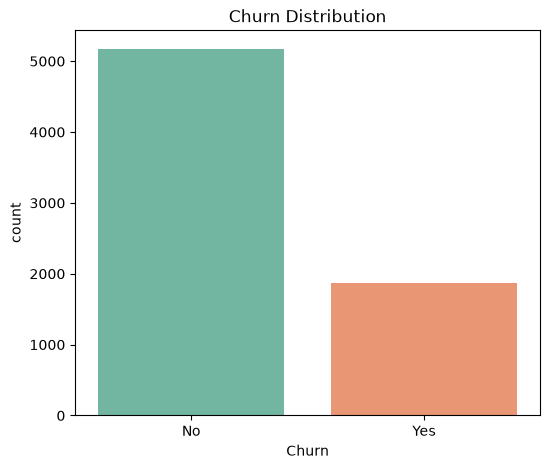

In [5]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print(churn_counts)
print(churn_pct)

plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Churn Distribution')
plt.savefig('../reports/churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

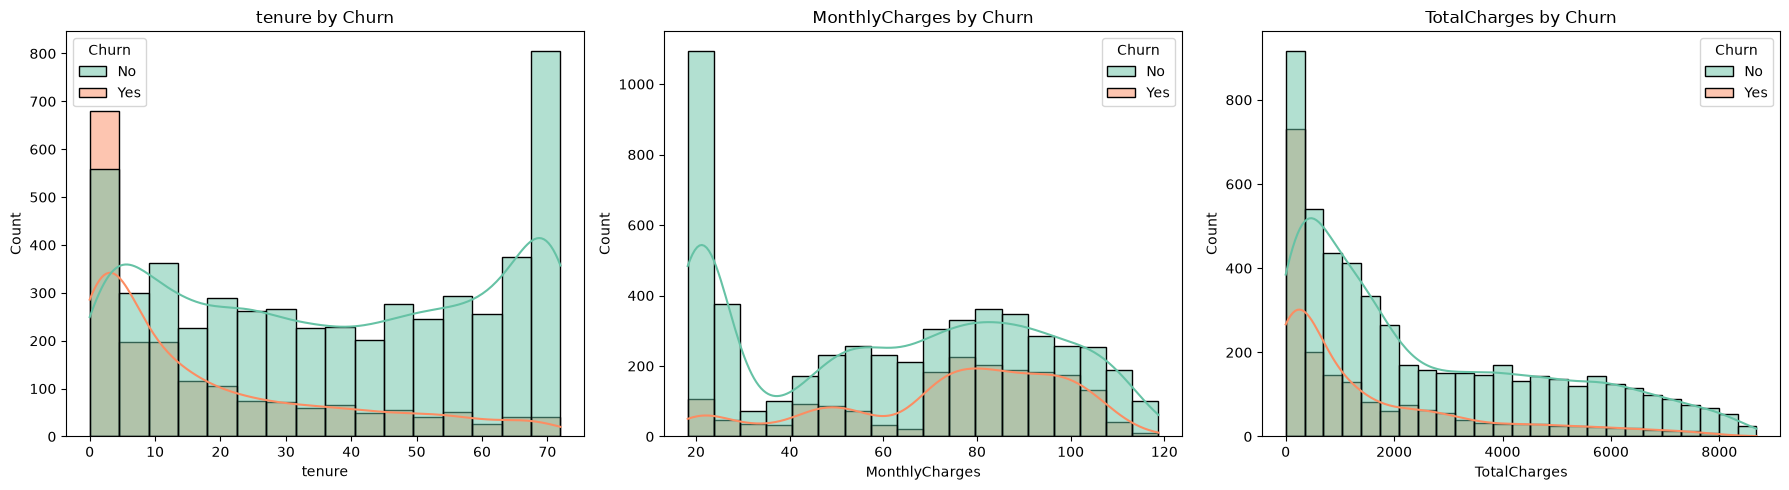

In [6]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, hue='Churn', kde=True, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} by Churn')
plt.tight_layout()
plt.savefig('../reports/numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

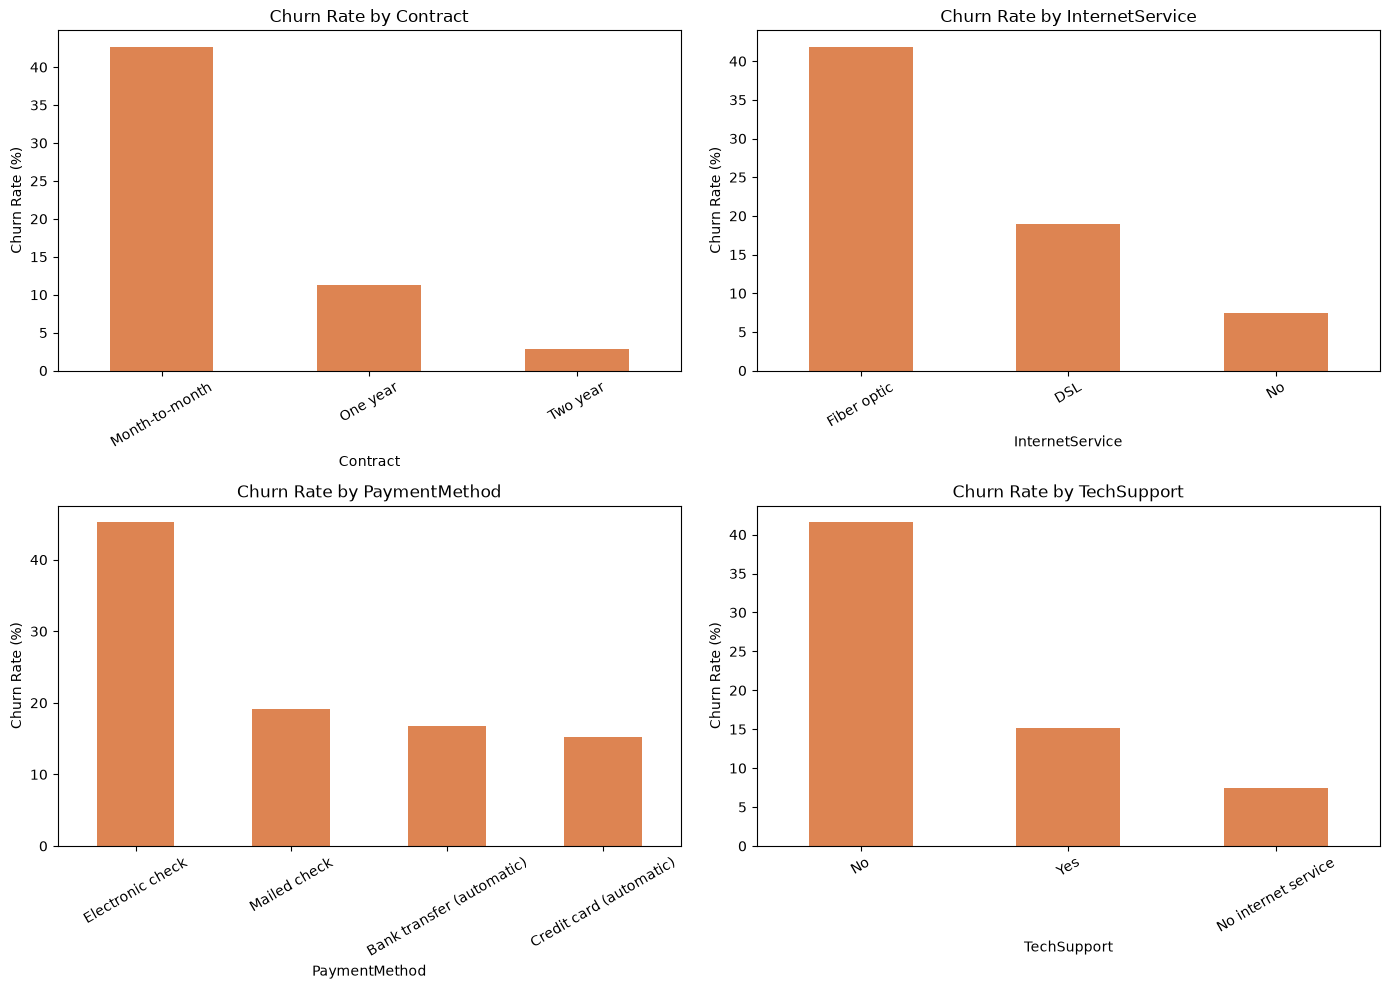

In [7]:
key_categoricals = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(key_categoricals):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    churn_rate.sort_values(ascending=False).plot(kind='bar', ax=axes[i], color='#DD8452')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('../reports/categorical_churn_rates.png', dpi=150, bbox_inches='tight')
plt.show()

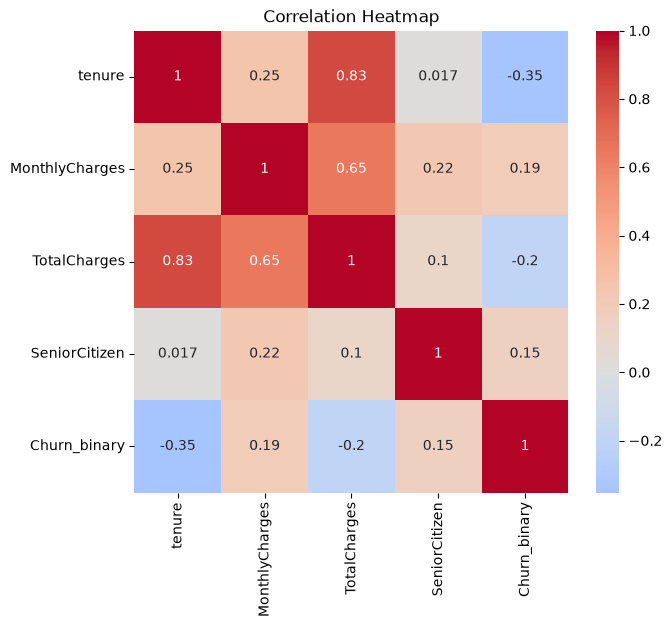

In [8]:
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)
numeric_with_target = df[numeric_cols + ['SeniorCitizen', 'Churn_binary']]

plt.figure(figsize=(7, 6))
sns.heatmap(numeric_with_target.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.savefig('../reports/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()